# 03 — EDA across the six MMDEC files

**Project:** Maritime Traffic & Environmental Performance Analytics

## What this notebook covers

The audit and first AIS movement review are in the earlier notebooks. This notebook extends the descriptive analysis to all six files: AIS positions, AIS specifications, the ship-type lookup, ERA5 weather, CMEMS ocean physics, and CMEMS waves. It covers numeric distributions, outlier checks, correlations, and relationships. Missingness, duplicate handling, and datatype decisions remain documented in the cleaning notebook.

The aim here is to describe what is in the local extract and decide which patterns are worth investigating. No prediction target or model has been selected yet, so these correlations are exploratory and do not show cause and effect.

## How unusual values are screened

The outlier screen below reports values more than three standard deviations above or below the mean. The interval from −3 SD to +3 SD spans six standard deviations. It is shown alongside the 1.5 × IQR rule, which is less affected by skewed data and extreme values.

Both methods flag candidates for review; neither automatically removes or replaces a value. AIS codes, vessel identifiers, timestamps, grid coordinates, directions, and special maximum codes are not treated as ordinary measurements. Physical limits and documented AIS meanings take priority over a statistical flag. Each result reports the denominator so the flagged share can be compared across files.

## 1. Set up the analysis

The cleaned copies are used so that already-verified duplicate handling and interpretation fields are available. Files are read one at a time where practical because AIS_POS and AIS_SPEC are large. The selection below excludes identifiers and codes from measurement summaries.

In [1]:
# Import tools for reading the cleaned files, calculating summaries, and drawing plots.
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Find the project root whether Jupyter starts in the project folder or notebooks folder.
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

# List the six cleaned outputs used in this cross-file EDA.
CLEAN = ROOT / "data" / "processed"
FILES = {
    "AIS_POS": CLEAN / "ais_positions_clean.parquet",
    "AIS_SPEC": CLEAN / "ais_specifications_clean.parquet",
    "AIS_ShipTypes": CLEAN / "ais_ship_types_clean.csv",
    "ERA5": CLEAN / "era5_clean.parquet",
    "CMEMS_PHY": CLEAN / "cmems_phy_clean.parquet",
    "CMEMS_WAV": CLEAN / "cmems_wav_clean.parquet",
}

# Stop with a clear list if the cleaning outputs are missing.
missing_outputs = [name for name, path in FILES.items() if not path.exists()]
if missing_outputs:
    raise FileNotFoundError(f"Run the cleaning notebook first; missing: {missing_outputs}")

# Display sizes so the reader can see which files are large before analysis.
display(pd.DataFrame([
    {"dataset": name, "file": path.name, "size_MiB": round(path.stat().st_size / 2**20, 1)}
    for name, path in FILES.items()
]))

,dataset,file,size_MiB
0,AIS_POS,ais_positions_clean.parquet,425.5
1,AIS_SPEC,ais_specifications_clean.parquet,235.5
2,AIS_ShipTypes,ais_ship_types_clean.csv,0.0
3,ERA5,era5_clean.parquet,13.9
4,CMEMS_PHY,cmems_phy_clean.parquet,77.9
5,CMEMS_WAV,cmems_wav_clean.parquet,41.4


## 2. Reusable distribution and outlier checks

For each continuous measurement, the summary reports the number of usable observations, range, median, mean, standard deviation, and the two outlier screens. The share is calculated using non-missing values in that field as the denominator. A high flag rate can simply reflect a skewed distribution, many zero readings, or a mixture of vessel types; context is needed before calling values erroneous.

In [2]:
# Calculate mean/standard-deviation and IQR outlier screens for one measurement.
def screen_outliers(values):
    # Record the total rows in the source table before excluding missing values.
    table_rows = len(values)
    # Convert the series to numeric values and exclude missing observations.
    x = pd.to_numeric(values, errors="coerce").dropna()
    # Return a clear empty result if this field contains no usable observations.
    if x.empty:
        return {"n_valid": 0}
    # Calculate the mean and population standard deviation for the three-standard-deviation rule.
    mean_value = x.mean()
    sd_value = x.std(ddof=0)
    # Set lower and upper bounds three standard deviations from the mean.
    sd_low = mean_value - 3 * sd_value
    sd_high = mean_value + 3 * sd_value
    # Calculate quartiles and the middle-half spread for the IQR rule.
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    # Set the usual 1.5-IQR fences below and above the middle half of observations.
    iqr_low = q1 - 1.5 * iqr
    iqr_high = q3 + 1.5 * iqr
    # Count values outside each pair of bounds without deleting or changing them.
    sd_low_count = int(x.lt(sd_low).sum())
    sd_high_count = int(x.gt(sd_high).sum())
    iqr_low_count = int(x.lt(iqr_low).sum())
    iqr_high_count = int(x.gt(iqr_high).sum())
    # Return thresholds, counts, and shares so each flag can be interpreted in context.
    return {
        "n_table_rows": int(table_rows),
        "n_valid": int(x.size),
        "min": float(x.min()),
        "median": float(x.median()),
        "mean": float(mean_value),
        "std_dev": float(sd_value),
        "max": float(x.max()),
        "3SD_low_bound": float(sd_low),
        "3SD_high_bound": float(sd_high),
        "3SD_low_n": sd_low_count,
        "3SD_high_n": sd_high_count,
        "3SD_valid_pct": 100 * (sd_low_count + sd_high_count) / x.size,
        "3SD_table_pct": 100 * (sd_low_count + sd_high_count) / table_rows if table_rows else np.nan,
        "IQR_low_fence": float(iqr_low),
        "IQR_high_fence": float(iqr_high),
        "IQR_low_n": iqr_low_count,
        "IQR_high_n": iqr_high_count,
        "IQR_valid_pct": 100 * (iqr_low_count + iqr_high_count) / x.size,
        "IQR_table_pct": 100 * (iqr_low_count + iqr_high_count) / table_rows if table_rows else np.nan,
    }

# Draw readable histograms for numeric measurements without including missing values.
def plot_distributions(frame, fields, title, columns=3):
    # Keep only fields that exist and contain at least one numeric observation.
    available = [field for field in fields if field in frame and frame[field].notna().any()]
    # Create enough panels to show each field without plotting unrelated codes.
    rows = math.ceil(len(available) / columns)
    figure, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.4 * rows), squeeze=False)
    # Draw one histogram per field and retain the field's original units on the x-axis.
    for axis, field in zip(axes.flat, available):
        frame[field].dropna().hist(ax=axis, bins=50, color="#2878a0")
        axis.set(title=field, xlabel="Value", ylabel="Rows")
        axis.grid(axis="y", alpha=0.2)
    # Hide unused panels when the number of variables is not a multiple of the columns.
    for axis in axes.flat[len(available):]:
        axis.set_visible(False)
    # Add a dataset-level title and keep labels readable.
    figure.suptitle(title, y=1.01)
    figure.tight_layout()
    plt.show()

# Compare variables with Pearson and rank-based Spearman correlations on a reproducible sample.
def show_correlations(frame, fields, title, max_rows=100_000):
    # Retain available fields and rows with at least two observed measurements.
    available = [field for field in fields if field in frame]
    sample = frame[available].dropna(how="all")
    # Sample large tables to limit memory and calculation time while keeping results repeatable.
    if len(sample) > max_rows:
        sample = sample.sample(n=max_rows, random_state=42)
    # Calculate linear Pearson and rank-based Spearman relationships for the selected fields.
    pearson = sample.corr(method="pearson", numeric_only=True)
    spearman = sample.corr(method="spearman", numeric_only=True)
    # Display both tables so the type of relationship is clear to the reader.
    print(f"{title}: {len(sample):,} rows used")
    display(pearson.round(2))
    display(spearman.round(2))
    # Plot the Spearman table as a heatmap for quick comparison of strong rank relationships.
    figure, axis = plt.subplots(figsize=(max(7, len(available) * 0.65), max(5, len(available) * 0.55)))
    image = axis.imshow(spearman, vmin=-1, vmax=1, cmap="coolwarm")
    axis.set_xticks(range(len(spearman.columns)), spearman.columns, rotation=70, ha="right")
    axis.set_yticks(range(len(spearman.index)), spearman.index)
    axis.set_title(f"{title}: Spearman correlation")
    figure.colorbar(image, ax=axis, label="Correlation (-1 to +1)")
    figure.tight_layout()
    plt.show()
    # Return the tables for later inspection without storing the sampled rows.
    return pearson, spearman

## 3. AIS_POS: movement measurements and the speed tail

The earlier AIS notebook already shows coverage, reporting gaps, status-code counts, and the location-density plot. This section adds the requested outlier comparison for cleaned SOG. Course and heading are angles, while MMSI, message type, navigation status, and coordinates are identifiers, codes, or locations; a standard correlation matrix across them would be misleading. The time-and-position relationships are better examined in the track and map views.

In [3]:
# Read only the cleaned speed and its upper-limit flag from the large movement file.
ais_pos = pd.read_parquet(FILES["AIS_POS"], columns=["sog_knots_clean", "sog_upper_code_flag", "sog_message27_unavailable_flag"])

# Apply both statistical screens to measured SOG, excluding missing and upper-censored codes.
ais_pos_outliers = pd.DataFrame([screen_outliers(ais_pos["sog_knots_clean"])], index=["SOG (knots)"])

# Show how many upper-limit codes were set aside from the measured-speed calculation.
ais_pos_outliers["AIS_102_2_upper_codes_excluded"] = int(ais_pos["sog_upper_code_flag"].fillna(False).sum())
ais_pos_outliers["AIS_Message27_63_unavailable_excluded"] = int(ais_pos["sog_message27_unavailable_flag"].fillna(False).sum())
display(ais_pos_outliers.T)

# Keep the source data and code flags; this EDA step marks candidates but removes none.
del ais_pos

,SOG (knots)
n_table_rows,1.897368e+07
n_valid,1.889852e+07
min,0.000000e+00
median,0.000000e+00
mean,3.081741e+00
std_dev,4.699215e+00
max,1.012000e+02
3SD_low_bound,-1.101591e+01
3SD_high_bound,1.717939e+01
3SD_low_n,0.000000e+00


### AIS_POS interpretation

SOG is strongly concentrated at low values, including zero, and has a long upper tail. The ±3 SD and IQR rules may flag different numbers because the distribution is not symmetric. These are review lists, not evidence that a vessel report is wrong. The four AIS upper-limit codes were already excluded from the measured-speed field during cleaning; other high values remain available for review by vessel, message type, and surrounding positions.

## 4. AIS_SPEC: vessel dimensions, draught, and vessel-type mix

AIS_SPEC is a stream of reports, not one row per vessel. Repeated reports would give frequently reporting vessels extra weight in a correlation or vessel-type count. Dimensions and draught are therefore summarized at vessel level using the median of available reports. AIS dimension maxima are upper-limit codes, so zero values and saturated maxima are counted separately and excluded from the statistical screen. Draught code 255 means 25.5 m or greater; it is flagged and excluded from the exact draught measurement ([IALA AIS guideline](https://www.iala.int/product/g1082/?download=true)).

,field,zero_unavailable_n,upper_limit_code_n
0,DimensionToBow,871726,307
1,DimensionToStern,1796829,164
2,DimensionToPort,1822349,163
3,DimensionToStarboard,1729287,1435


AIS draught code counts: {'unavailable_code_0': 523846, 'exact_values_1_to_254': 3811655, 'upper_limit_code_255': 179}


,n_table_rows,n_valid,min,median,mean,std_dev,max,3SD_low_bound,3SD_high_bound,3SD_low_n,3SD_high_n,3SD_valid_pct,3SD_table_pct,IQR_low_fence,IQR_high_fence,IQR_low_n,IQR_high_n,IQR_valid_pct,IQR_table_pct
DimensionToBow,13547406.0,12675268.0,1.0,10.0,28.544,47.771,509.0,-114.768,171.857,0.0,379590.0,2.995,2.802,-9.0,31.0,0.0,2241839.0,17.687,16.548
DimensionToStern,13547406.0,11750308.0,1.0,6.0,16.352,33.954,499.0,-85.509,118.213,0.0,347928.0,2.961,2.568,-8.0,24.0,0.0,1553653.0,13.222,11.468
DimensionToPort,13547406.0,11724789.0,1.0,3.0,4.786,5.455,62.0,-11.580,21.152,0.0,334027.0,2.849,2.466,-2.5,9.5,0.0,1483544.0,12.653,10.951
DimensionToStarboard,13547406.0,11816579.0,1.0,3.0,4.679,5.417,62.0,-11.571,20.929,0.0,379000.0,3.207,2.798,-2.5,9.5,0.0,1465594.0,12.403,10.818
Draught (m),13547406.0,3811655.0,0.1,5.3,5.797,3.323,25.0,-4.171,15.764,0.0,22835.0,0.599,0.169,-2.5,13.5,0.0,113495.0,2.978,0.838


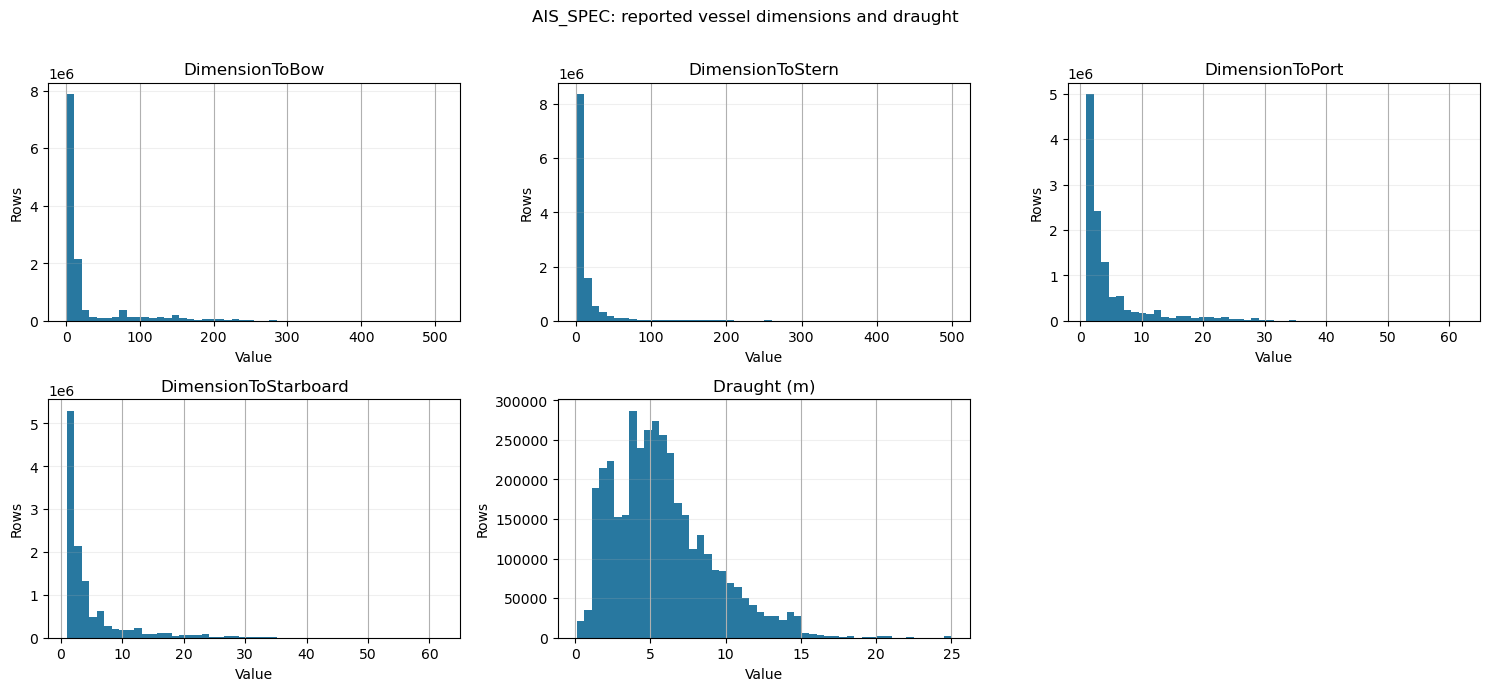

AIS_SPEC vessel-level measurements: 22,579 rows used


,DimensionToBow,DimensionToStern,DimensionToPort,DimensionToStarboard,Draught (m)
DimensionToBow,1.00,0.36,0.82,0.82,0.76
DimensionToStern,0.36,1.00,0.62,0.62,0.37
DimensionToPort,0.82,0.62,1.00,0.65,0.68
DimensionToStarboard,0.82,0.62,0.65,1.00,0.68
Draught (m),0.76,0.37,0.68,0.68,1.00


,DimensionToBow,DimensionToStern,DimensionToPort,DimensionToStarboard,Draught (m)
DimensionToBow,1.00,0.58,0.74,0.75,0.78
DimensionToStern,0.58,1.00,0.76,0.77,0.63
DimensionToPort,0.74,0.76,1.00,0.64,0.72
DimensionToStarboard,0.75,0.77,0.64,1.00,0.71
Draught (m),0.78,0.63,0.72,0.71,1.00


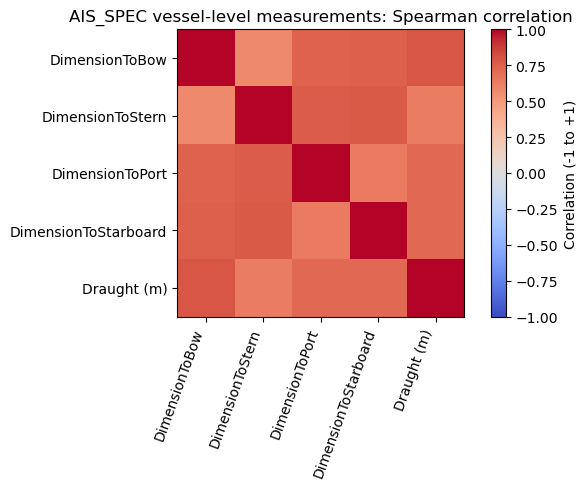

,vessels
ship type,
Pleasure Craft/Sailing,14308
Cargo,4193
Tanker,2259
Other,1365
Fishing,1090
Passenger,347
Tug Tow,228


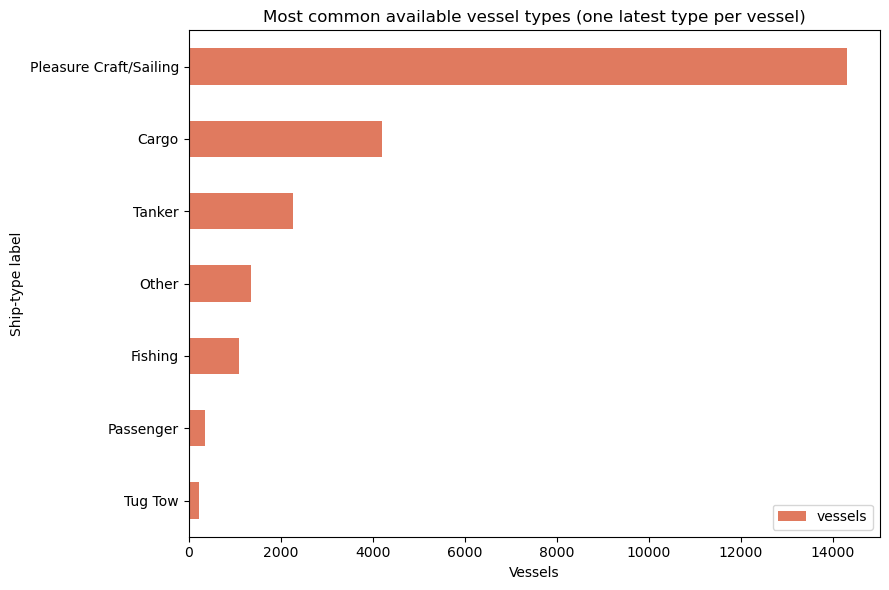

,reports with valid part (%)
eta_month_clean,25.58
eta_day_clean,25.68
eta_hour_clean,27.39
eta_minute_clean,27.39


In [4]:
# Load vessel identifier, time, vessel type, dimensions, and cleaned draught only.
ais_spec = pd.read_parquet(FILES["AIS_SPEC"], columns=[
    "Mmsi", "Date_utc", "ShipType", "DimensionToBow", "DimensionToStern",
    "DimensionToPort", "DimensionToStarboard", "Draught10thMetres",
    "draught_unavailable_flag", "draught_upper_code_flag", "draught_m_clean",
    "eta_month_clean", "eta_day_clean", "eta_hour_clean", "eta_minute_clean",
    "PositionFixType", "ship_type_label"
])

# Define documented upper codes for AIS vessel dimensions, in metres.
dimension_limits = {
    "DimensionToBow": 511,
    "DimensionToStern": 511,
    "DimensionToPort": 63,
    "DimensionToStarboard": 63,
}

# Count unavailable zero values and upper-coded dimensions before applying statistical screens.
dimension_code_rows = []
for field, upper_code in dimension_limits.items():
    dimension_code_rows.append({
        "field": field,
        "zero_unavailable_n": int(ais_spec[field].eq(0).sum()),
        "upper_limit_code_n": int(ais_spec[field].eq(upper_code).sum()),
    })
display(pd.DataFrame(dimension_code_rows))

# Count unavailable, exact, and upper-limit draught values in the AIS reports.
draught_code_profile = {
    "unavailable_code_0": int(ais_spec["draught_unavailable_flag"].sum()),
    "exact_values_1_to_254": int(ais_spec["Draught10thMetres"].between(1, 254).sum()),
    "upper_limit_code_255": int(ais_spec["draught_upper_code_flag"].sum()),
}
print("AIS draught code counts:", draught_code_profile)

# Exclude zero and saturated codes; keep only exact dimension values for outlier screening.
dimension_measurements = {}
for field, upper_code in dimension_limits.items():
    dimension_measurements[field] = ais_spec[field].where(
        ais_spec[field].gt(0) & ais_spec[field].lt(upper_code)
    )

# Add draught in metres; unavailable and upper-limit codes are not exact measurements.
dimension_measurements["Draught (m)"] = ais_spec["draught_m_clean"]

# Summarize both screening rules for each vessel measurement.
ais_spec_outliers = pd.DataFrame({
    field: screen_outliers(values) for field, values in dimension_measurements.items()
}).T
display(ais_spec_outliers.round(3))

# Plot the distributions while retaining the source units (metres).
plot_distributions(pd.DataFrame(dimension_measurements), list(dimension_measurements),
                   "AIS_SPEC: reported vessel dimensions and draught")

# Build one row per MMSI using medians so repeated messages do not overweight vessels.
vessel_measurements = pd.DataFrame(dimension_measurements, index=ais_spec.index)
vessel_measurements["Mmsi"] = ais_spec["Mmsi"].to_numpy()
vessel_profile = vessel_measurements.groupby("Mmsi", sort=False).median(numeric_only=True)

# Compare relationships among vessel dimensions and draught at vessel level.
ais_spec_pearson, ais_spec_spearman = show_correlations(
    vessel_profile, list(dimension_measurements), "AIS_SPEC vessel-level measurements"
)

# Keep the latest available non-zero ship type for each vessel for a representative type profile.
known_types = ais_spec.loc[ais_spec["ShipType"].notna() & ais_spec["ShipType"].ne(0)].sort_values("Date_utc")
latest_vessel_type = known_types.drop_duplicates("Mmsi", keep="last")
ship_type_counts = latest_vessel_type["ship_type_label"].value_counts().rename_axis("ship type").to_frame("vessels")

display(ship_type_counts.head(20))

# Plot the most common vessel types; this is a count of vessels, not AIS message frequency.
ship_type_counts.head(20).sort_values("vessels").plot(kind="barh", figsize=(9, 6), color="#e07a5f")
plt.title("Most common available vessel types (one latest type per vessel)")
plt.xlabel("Vessels")
plt.ylabel("Ship-type label")
plt.tight_layout()
plt.show()

# Count valid cleaned ETA parts as descriptive availability, not as a time-to-arrival measure.
eta_availability = ais_spec[["eta_month_clean", "eta_day_clean", "eta_hour_clean", "eta_minute_clean"]].notna().mean().mul(100)
display(eta_availability.rename("reports with valid part (%)").to_frame().round(2))

# Release large AIS_SPEC tables before moving to the environmental grids.
del ais_spec, dimension_measurements, vessel_measurements, latest_vessel_type, known_types

### AIS_SPEC interpretation

Dimension and draught flags should be read alongside the missing and upper-code counts. AIS dimensions are reported as distances from the vessel reference point to its bow, stern, port side, and starboard side; they are not four independent overall vessel lengths or beam measurements. Correlation is calculated after reducing the report stream to one median profile per MMSI, which avoids counting a vessel repeatedly just because it transmitted more often. It remains descriptive: reported dimensions and draught may be incomplete or stale, and do not establish a design relationship.

## 5. AIS_ShipTypes: describe the lookup without treating codes as measurements

The lookup contains labels rather than vessel observations. Numeric ship-type codes are categories, so standard deviation and correlation are not appropriate. The vessel counts above use the AIS_SPEC stream to show how the available labels are represented in this extract; the lookup itself supplies the definitions. Code 0 (“Not available”) is excluded from the representative known-type count.

In [5]:
# Load the compact lookup and show how many codes belong to each broad label.
ship_types = pd.read_csv(FILES["AIS_ShipTypes"])

# Count lookup rows by broad type label; this describes the reference table, not fleet size.
lookup_label_counts = ship_types.groupby("Type", dropna=False).size().sort_values(ascending=False).rename("codes")
display(lookup_label_counts.to_frame())

# Confirm the lookup key remains unique and that every observed non-zero AIS code has a label.
observed_codes = pd.read_parquet(FILES["AIS_SPEC"], columns=["ShipType"])["ShipType"].dropna().astype(int).unique()
lookup_code_set = set(ship_types["Code"].astype(int))
lookup_check = {
    "lookup_rows": len(ship_types),
    "unique_codes": int(ship_types["Code"].nunique()),
    "observed_nonzero_codes_without_label": sorted(set(observed_codes) - lookup_code_set),
}
print(lookup_check)

,codes
Type,
Other,219
Cargo,10
Passenger,10
Tanker,10
Tug Tow,3
Pleasure Craft/Sailing,2
Fishing,1
Not available,1


{'lookup_rows': 256, 'unique_codes': 256, 'observed_nonzero_codes_without_label': []}


## 6. Environmental grids: distributions, unusual values, and correlations

Environmental measurements are checked within their own product and units. Time and grid coordinates are not included as measured variables. The wave directions are circular (0° and 360° point the same way), so they are summarized and plotted but left out of ordinary Pearson/Spearman matrices. For correlation and histograms, a fixed random sample is used when a grid is large; outlier counts and percentages are calculated from the full selected measurement columns.

ERA5: outlier screens (all available rows)


,n_table_rows,n_valid,min,median,mean,std_dev,max,3SD_low_bound,3SD_high_bound,3SD_low_n,3SD_high_n,3SD_valid_pct,3SD_table_pct,IQR_low_fence,IQR_high_fence,IQR_low_n,IQR_high_n,IQR_valid_pct,IQR_table_pct
sp,537510.0,537510.0,973.196,1013.809,1012.770,7.098,1027.344,991.476,1034.064,3559.0,0.0,0.662,0.662,997.290,1029.090,15971.0,0.0,2.971,2.971
msl,537510.0,537510.0,983.941,1015.055,1014.119,6.871,1027.851,993.507,1034.732,3124.0,0.0,0.581,0.581,1000.217,1028.850,18407.0,0.0,3.424,3.424
tcc_fraction_clean,537510.0,537510.0,0.000,0.692,0.625,0.342,1.000,-0.401,1.650,0.0,0.0,0.000,0.000,-0.653,1.947,0.0,0.0,0.000,0.000
u10,537510.0,537510.0,-11.316,4.027,3.358,4.457,19.414,-10.013,16.728,414.0,293.0,0.132,0.132,-8.531,15.517,3111.0,735.0,0.716,0.716
v10,537510.0,537510.0,-12.150,1.098,1.321,4.042,18.558,-10.805,13.447,82.0,1274.0,0.252,0.252,-9.655,12.124,470.0,3131.0,0.670,0.670
t2m,537510.0,537510.0,8.168,17.085,17.258,1.605,30.084,12.442,22.074,1258.0,6992.0,1.535,1.535,13.818,20.483,6540.0,19573.0,4.858,4.858
d2m,537510.0,537510.0,6.244,14.634,14.412,2.154,22.028,7.951,20.873,1951.0,147.0,0.390,0.390,8.132,20.701,2240.0,247.0,0.463,0.463


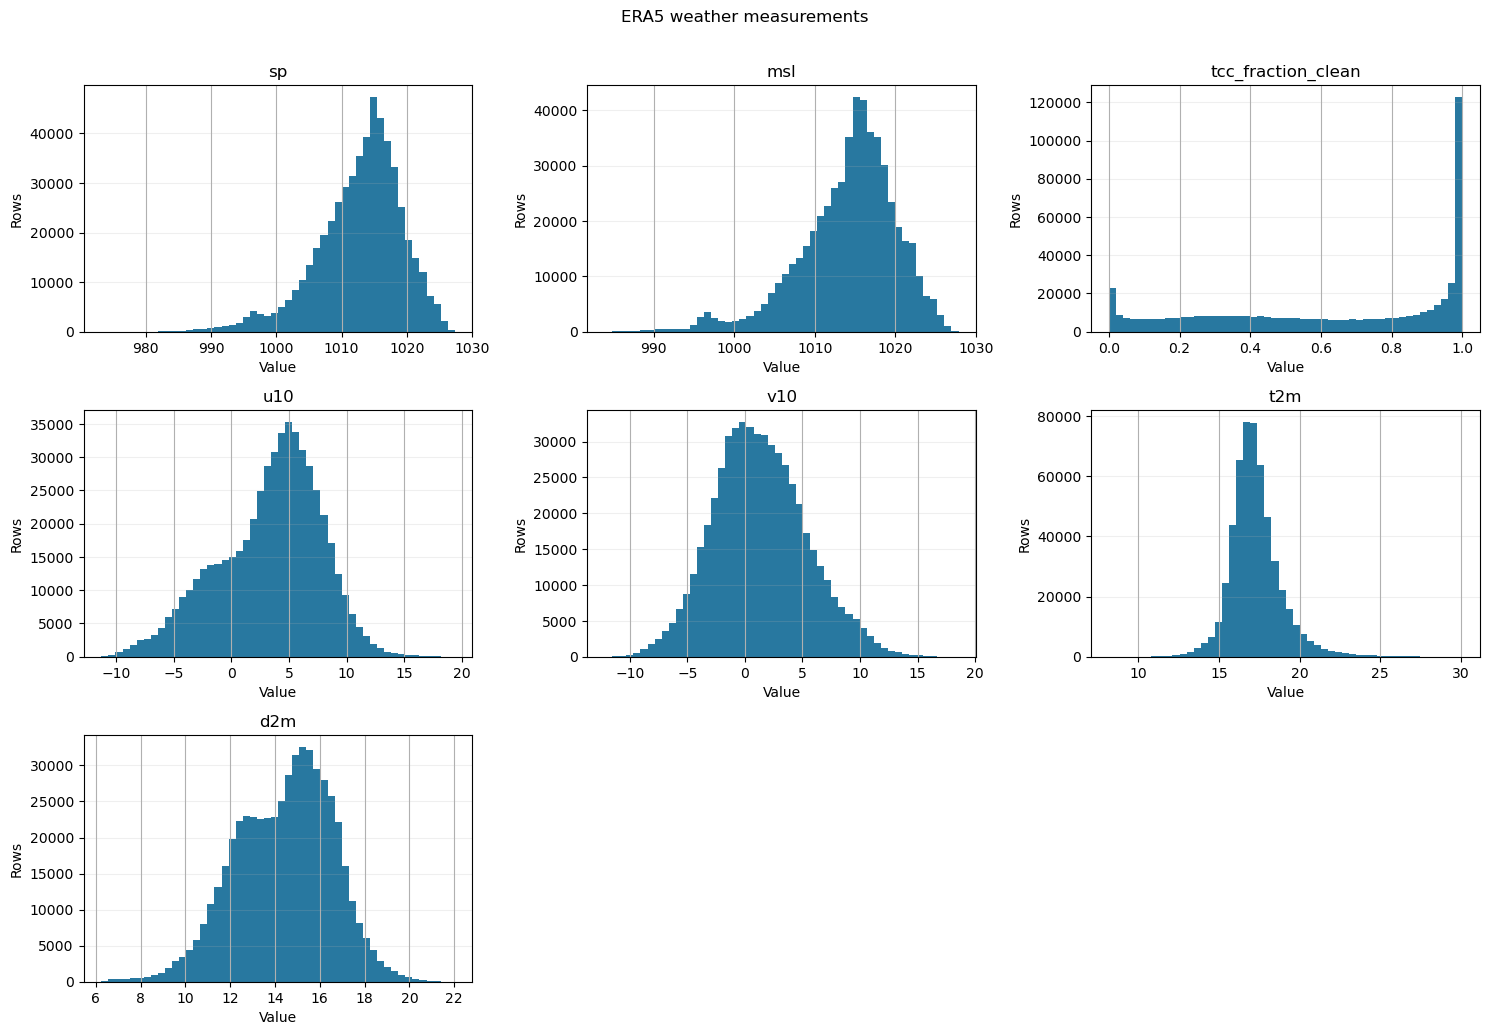

ERA5 sampled measurements: 100,000 rows used


,sp,msl,tcc_fraction_clean,u10,v10,t2m,d2m
sp,1.00,0.94,-0.24,-0.30,-0.25,0.05,0.02
msl,0.94,1.00,-0.25,-0.35,-0.27,0.07,0.01
tcc_fraction_clean,-0.24,-0.25,1.00,0.17,0.27,-0.01,0.08
u10,-0.30,-0.35,0.17,1.00,0.15,-0.38,-0.38
v10,-0.25,-0.27,0.27,0.15,1.00,0.12,0.20
t2m,0.05,0.07,-0.01,-0.38,0.12,1.00,0.69
d2m,0.02,0.01,0.08,-0.38,0.20,0.69,1.00


,sp,msl,tcc_fraction_clean,u10,v10,t2m,d2m
sp,1.00,0.92,-0.27,-0.30,-0.23,0.00,0.00
msl,0.92,1.00,-0.28,-0.37,-0.25,0.00,-0.01
tcc_fraction_clean,-0.27,-0.28,1.00,0.15,0.30,0.04,0.12
u10,-0.30,-0.37,0.15,1.00,0.17,-0.35,-0.38
v10,-0.23,-0.25,0.30,0.17,1.00,0.17,0.20
t2m,0.00,0.00,0.04,-0.35,0.17,1.00,0.74
d2m,0.00,-0.01,0.12,-0.38,0.20,0.74,1.00


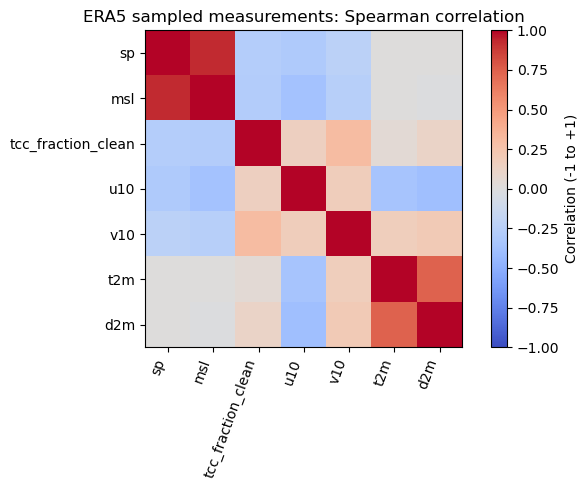

CMEMS_PHY: outlier screens (all available rows)


,n_table_rows,n_valid,min,median,mean,std_dev,max,3SD_low_bound,3SD_high_bound,3SD_low_n,3SD_high_n,3SD_valid_pct,3SD_table_pct,IQR_low_fence,IQR_high_fence,IQR_low_n,IQR_high_n,IQR_valid_pct,IQR_table_pct
so,5007803.0,4605765.0,31.390,34.841,34.728,1.551,35.738,30.075,39.381,0.0,0.0,0.000,0.000,33.986,35.612,400386.0,23620.0,9.206,8.467
thetao,5007803.0,4605765.0,10.594,17.439,17.563,1.382,23.312,13.416,21.709,15406.0,5173.0,0.447,0.411,13.992,21.122,32143.0,28010.0,1.306,1.201
uo,5007803.0,4605765.0,-0.563,0.040,0.045,0.108,0.908,-0.280,0.369,8981.0,33327.0,0.919,0.845,-0.218,0.302,33804.0,80445.0,2.481,2.281
vo,5007803.0,4605765.0,-0.567,-0.002,-0.003,0.092,1.077,-0.278,0.272,14997.0,33286.0,1.048,0.964,-0.208,0.201,75496.0,80531.0,3.388,3.116
zos,5007803.0,4605765.0,-0.942,-0.313,-0.307,0.069,0.425,-0.513,-0.101,6101.0,59249.0,1.419,1.305,-0.454,-0.169,52131.0,190845.0,5.275,4.852


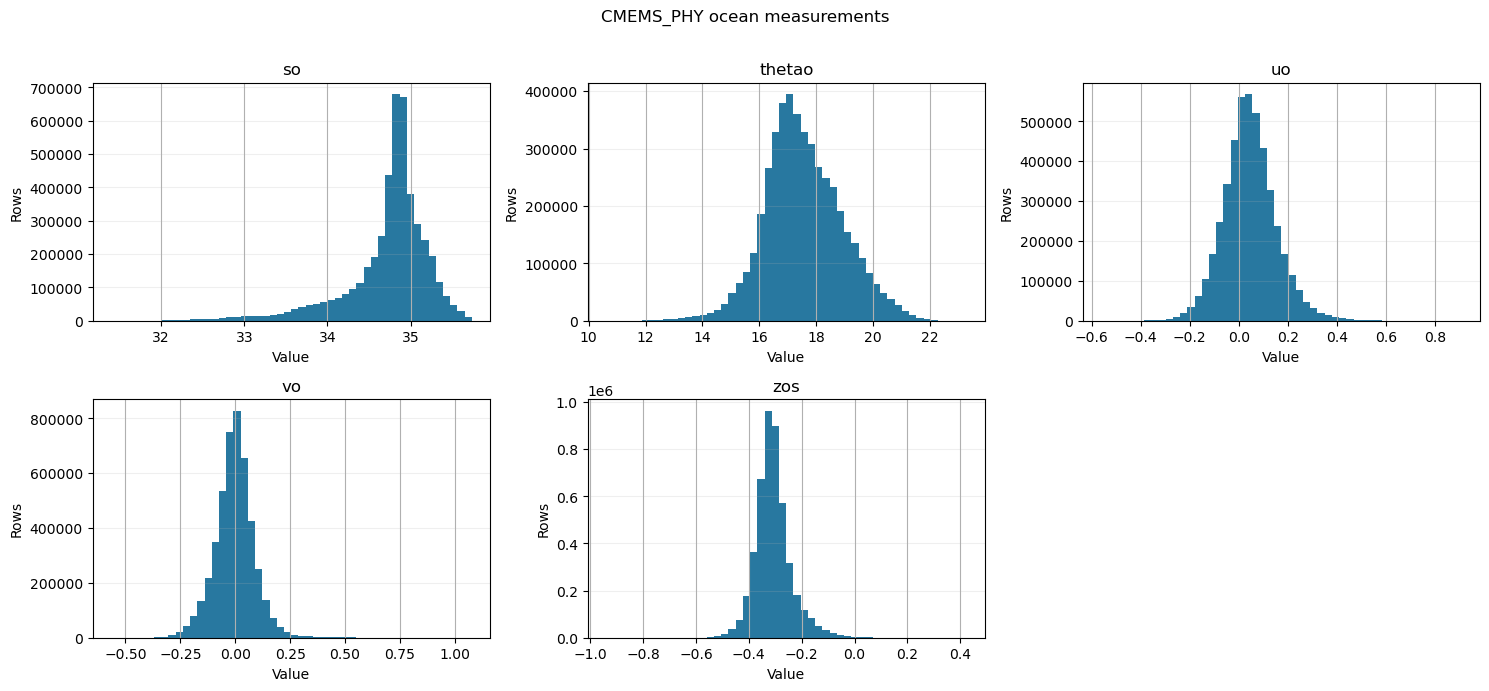

CMEMS_PHY sampled measurements: 100,000 rows used


,so,thetao,uo,vo,zos
so,1.00,-0.46,-0.03,-0.19,-0.24
thetao,-0.46,1.00,-0.23,0.13,0.30
uo,-0.03,-0.23,1.00,0.17,0.07
vo,-0.19,0.13,0.17,1.00,0.20
zos,-0.24,0.30,0.07,0.20,1.00


,so,thetao,uo,vo,zos
so,1.00,-0.44,-0.03,-0.18,-0.19
thetao,-0.44,1.00,-0.22,0.16,0.33
uo,-0.03,-0.22,1.00,0.11,0.07
vo,-0.18,0.16,0.11,1.00,0.20
zos,-0.19,0.33,0.07,0.20,1.00


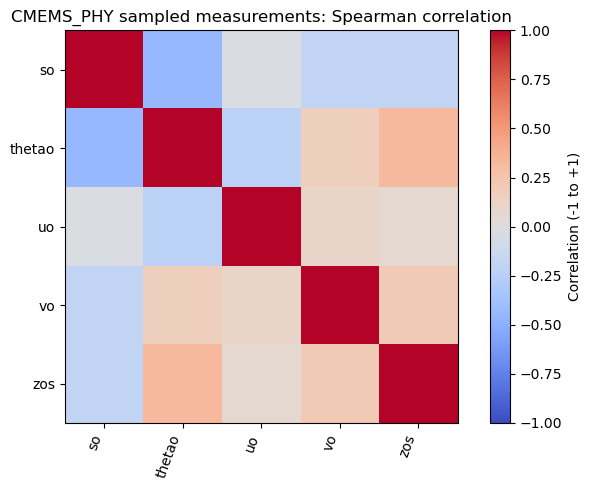

CMEMS_WAV: outlier screens (all available rows)


,n_table_rows,n_valid,min,median,mean,std_dev,max,3SD_low_bound,3SD_high_bound,3SD_low_n,3SD_high_n,3SD_valid_pct,3SD_table_pct,IQR_low_fence,IQR_high_fence,IQR_low_n,IQR_high_n,IQR_valid_pct,IQR_table_pct
VCMX,1670779.0,1468841.0,0.04,2.15,2.526,1.663,13.53,-2.462,7.514,0.0,18070.0,1.230,1.082,-1.750,6.410,0.0,44430.0,3.025,2.659
VHM0,1670779.0,1468841.0,0.02,1.13,1.342,0.889,7.27,-1.324,4.008,0.0,18620.0,1.268,1.114,-0.945,3.415,0.0,45781.0,3.117,2.740
VHM0_SW1,1670779.0,1468841.0,0.01,0.73,0.923,0.719,5.81,-1.235,3.082,0.0,21470.0,1.462,1.285,-0.860,2.500,0.0,63276.0,4.308,3.787
VHM0_SW2,1670779.0,1468841.0,0.00,0.17,0.257,0.269,3.42,-0.549,1.063,0.0,33088.0,2.253,1.980,-0.270,0.690,0.0,94251.0,6.417,5.641
VHM0_WW,1670779.0,1468841.0,0.00,0.50,0.692,0.716,7.14,-1.457,2.841,0.0,25345.0,1.726,1.517,-1.045,2.195,0.0,63346.0,4.313,3.791
VSDX,1670779.0,1468841.0,-0.16,0.05,0.051,0.057,0.37,-0.121,0.223,1598.0,5162.0,0.460,0.405,-0.110,0.210,8706.0,8928.0,1.201,1.055
VSDY,1670779.0,1468841.0,-0.17,0.01,0.018,0.048,0.33,-0.127,0.163,1227.0,10395.0,0.791,0.696,-0.100,0.140,6815.0,27845.0,2.360,2.074
VTM01_SW1,1670779.0,1468841.0,1.30,6.29,6.436,1.913,16.66,0.698,12.175,0.0,14472.0,0.985,0.866,1.645,11.045,261.0,36974.0,2.535,2.229
VTM01_SW2,1670779.0,1468841.0,0.84,5.89,7.051,3.847,23.91,-4.490,18.592,0.0,8561.0,0.583,0.512,-2.705,15.895,0.0,41313.0,2.813,2.473
VTM01_WW,1670779.0,1468841.0,0.00,2.77,2.819,1.541,9.86,-1.802,7.441,0.0,5508.0,0.375,0.330,-1.045,6.675,0.0,16275.0,1.108,0.974


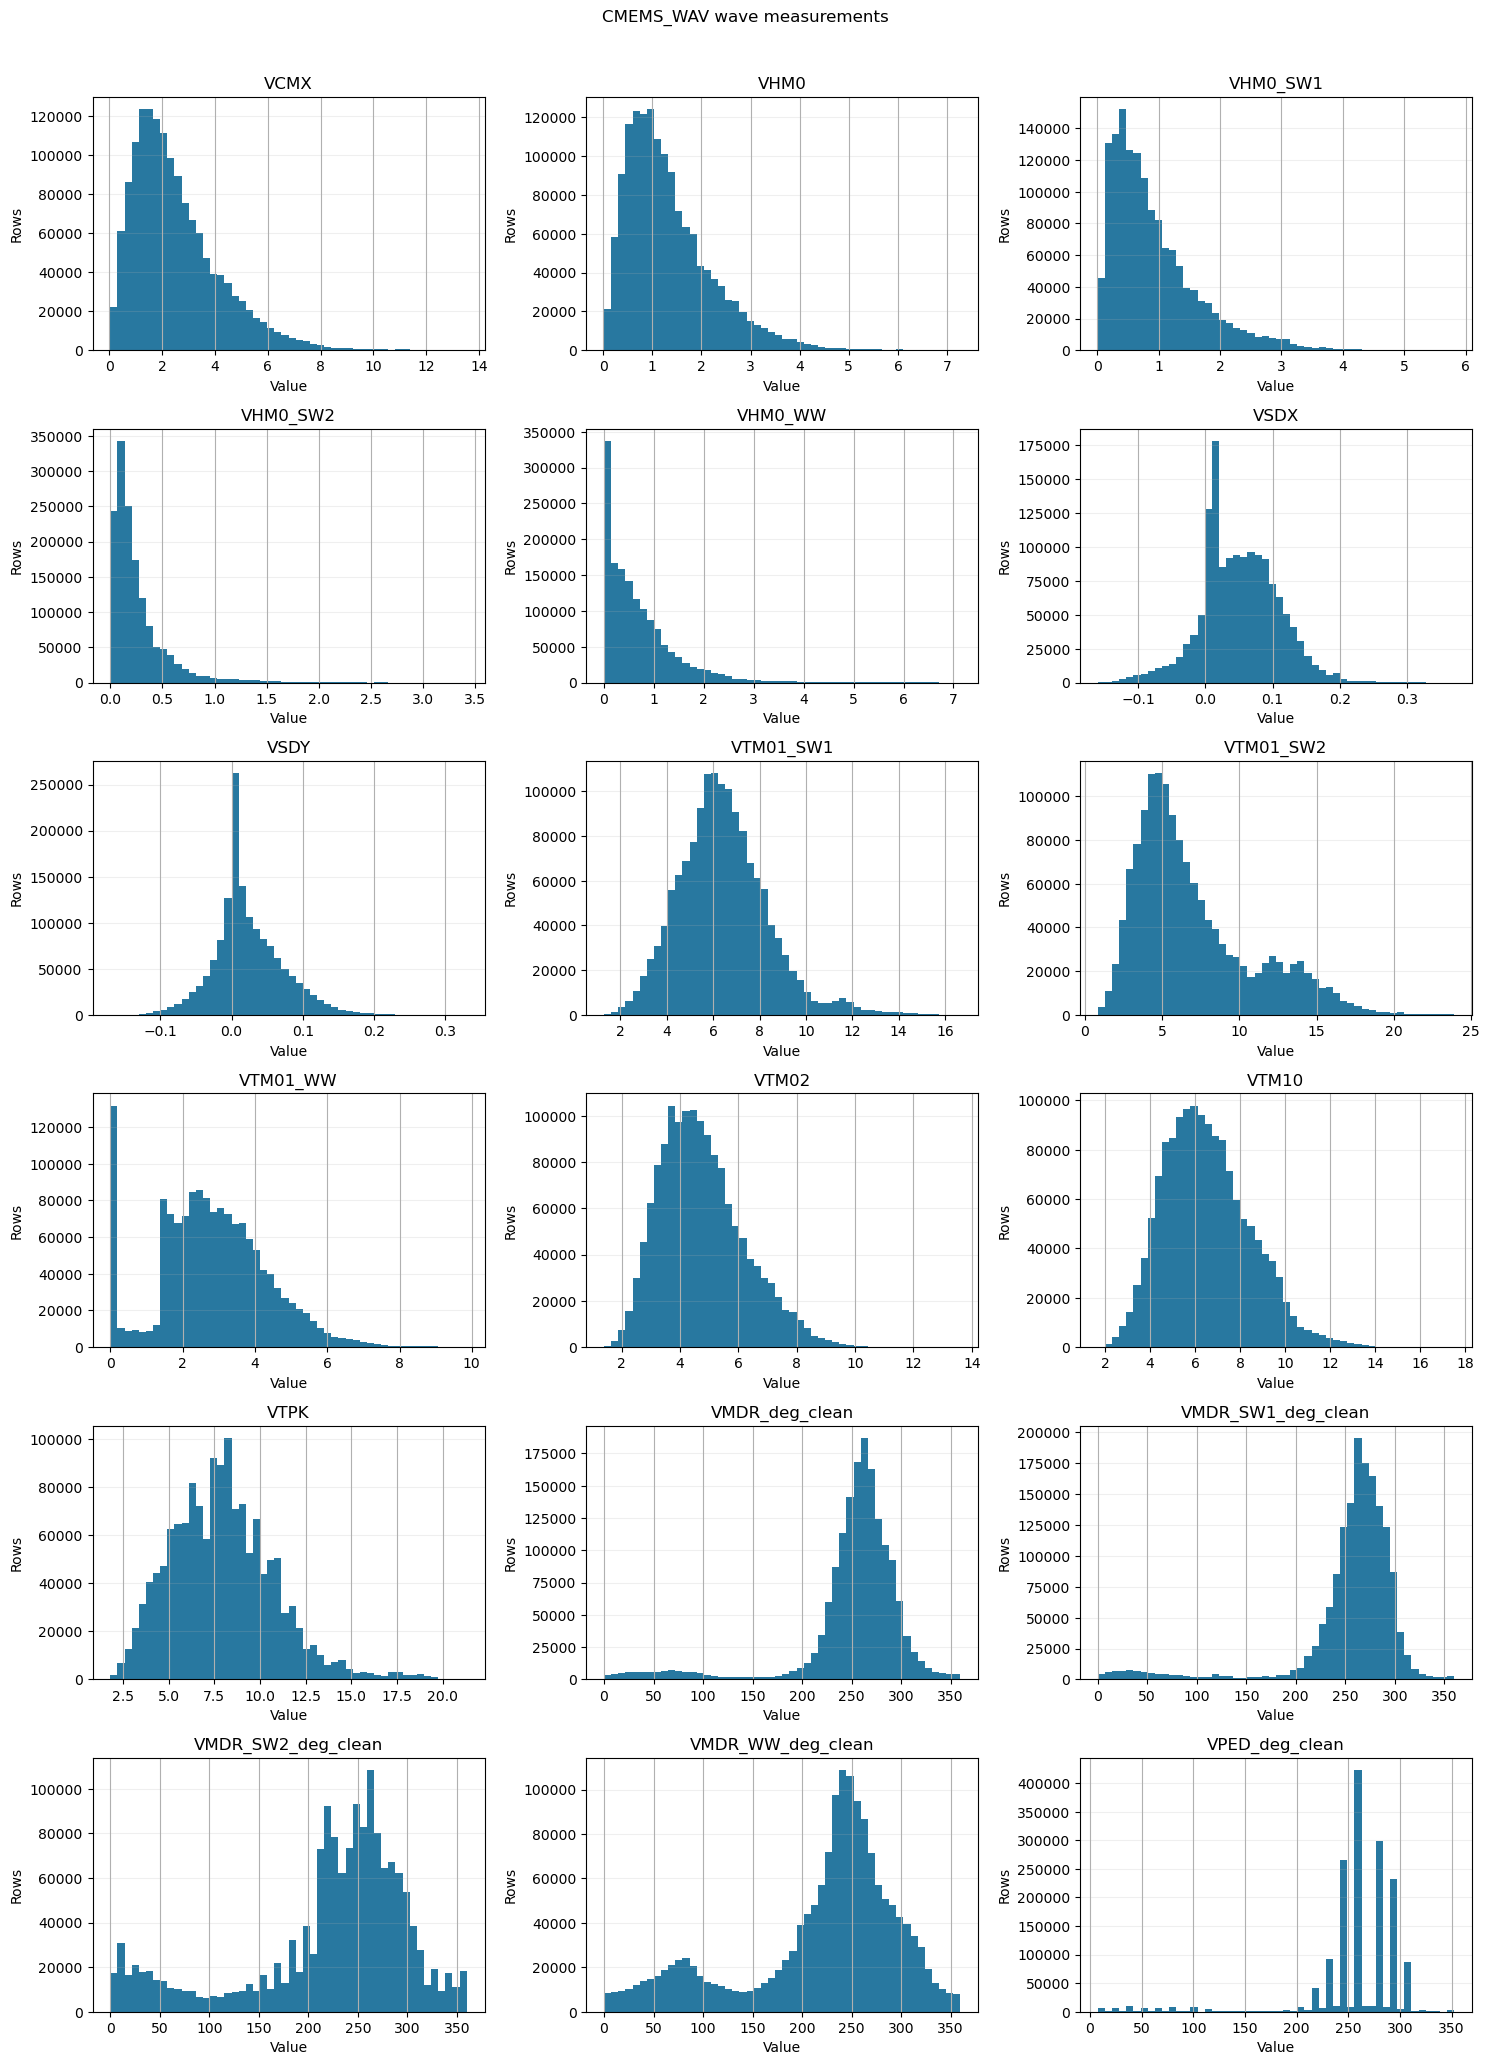

CMEMS_WAV sampled measurements: 100,000 rows used


,VCMX,VHM0,VHM0_SW1,VHM0_SW2,VHM0_WW,VSDX,VSDY,VTM01_SW1,VTM01_SW2,VTM01_WW,VTM02,VTM10,VTPK
VCMX,1.00,1.00,0.78,0.44,0.78,0.64,0.31,0.53,0.10,0.74,0.65,0.51,0.37
VHM0,1.00,1.00,0.80,0.44,0.76,0.64,0.30,0.53,0.10,0.72,0.66,0.52,0.38
VHM0_SW1,0.78,0.80,1.00,0.31,0.26,0.36,0.10,0.45,0.11,0.31,0.72,0.66,0.52
VHM0_SW2,0.44,0.44,0.31,1.00,0.26,0.14,0.12,0.27,0.03,0.26,0.32,0.31,0.26
VHM0_WW,0.78,0.76,0.26,0.26,1.00,0.69,0.39,0.34,-0.00,0.92,0.22,0.07,0.02
VSDX,0.64,0.64,0.36,0.14,0.69,1.00,0.21,0.16,-0.04,0.69,0.23,0.05,-0.02
VSDY,0.31,0.30,0.10,0.12,0.39,0.21,1.00,0.12,0.02,0.35,0.09,0.03,0.00
VTM01_SW1,0.53,0.53,0.45,0.27,0.34,0.16,0.12,1.00,0.00,0.29,0.64,0.74,0.70
VTM01_SW2,0.10,0.10,0.11,0.03,-0.00,-0.04,0.02,0.00,1.00,-0.05,0.19,0.18,0.13
VTM01_WW,0.74,0.72,0.31,0.26,0.92,0.69,0.35,0.29,-0.05,1.00,0.10,-0.02,-0.03


,VCMX,VHM0,VHM0_SW1,VHM0_SW2,VHM0_WW,VSDX,VSDY,VTM01_SW1,VTM01_SW2,VTM01_WW,VTM02,VTM10,VTPK
VCMX,1.00,1.00,0.76,0.40,0.74,0.67,0.31,0.55,0.15,0.74,0.66,0.50,0.38
VHM0,1.00,1.00,0.77,0.40,0.72,0.67,0.30,0.56,0.15,0.73,0.68,0.51,0.40
VHM0_SW1,0.76,0.77,1.00,0.27,0.28,0.36,0.10,0.46,0.10,0.29,0.75,0.68,0.59
VHM0_SW2,0.40,0.40,0.27,1.00,0.31,0.16,0.07,0.22,0.13,0.32,0.23,0.22,0.17
VHM0_WW,0.74,0.72,0.28,0.31,1.00,0.74,0.36,0.30,0.02,1.00,0.11,-0.04,-0.06
VSDX,0.67,0.67,0.36,0.16,0.74,1.00,0.25,0.23,0.02,0.75,0.24,0.05,-0.00
VSDY,0.31,0.30,0.10,0.07,0.36,0.25,1.00,0.14,0.02,0.34,0.10,0.02,0.00
VTM01_SW1,0.55,0.56,0.46,0.22,0.30,0.23,0.14,1.00,-0.03,0.30,0.68,0.75,0.73
VTM01_SW2,0.15,0.15,0.10,0.13,0.02,0.02,0.02,-0.03,1.00,0.02,0.19,0.16,0.04
VTM01_WW,0.74,0.73,0.29,0.32,1.00,0.75,0.34,0.30,0.02,1.00,0.13,-0.03,-0.05


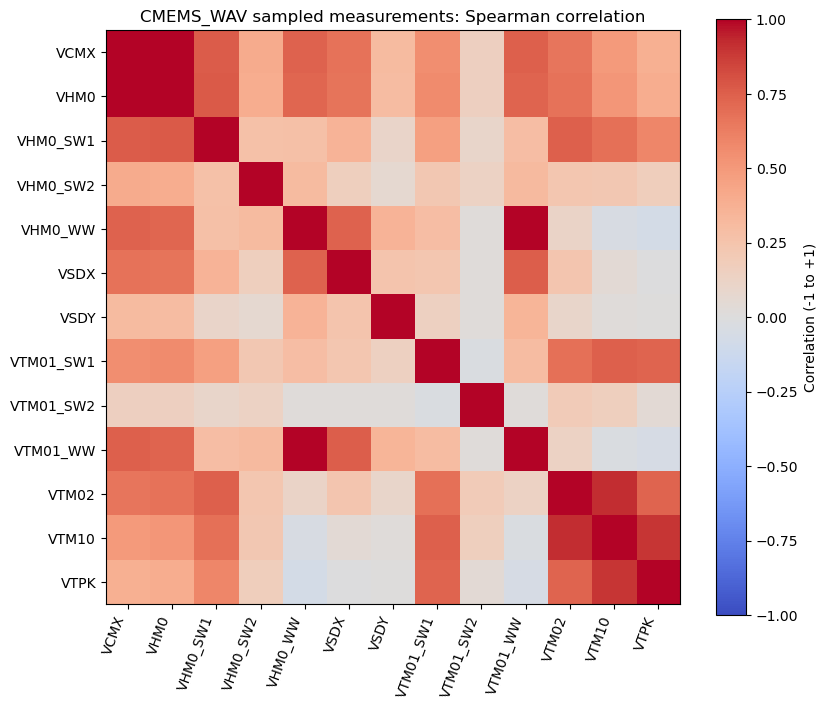

Wave direction counts by 45-degree interval; angles are excluded from ordinary correlation.
VMDR_deg_clean


,grid rows
"[0, 45)",31127
"[45, 90)",39329
"[90, 135)",19371
"[135, 180)",11948
"[180, 225)",98846
"[225, 270)",830095
"[270, 315)",509520
"[315, 360)",45788


VMDR_SW1_deg_clean


,grid rows
"[0, 45)",40256
"[45, 90)",25335
"[90, 135)",16384
"[135, 180)",12787
"[180, 225)",78882
"[225, 270)",726747
"[270, 315)",659879
"[315, 360)",25754


VMDR_SW2_deg_clean


,grid rows
"[0, 45)",125346
"[45, 90)",67873
"[90, 135)",47143
"[135, 180)",85737
"[180, 225)",299957
"[225, 270)",525228
"[270, 315)",343645
"[315, 360)",91095


VMDR_WW_deg_clean


,grid rows
"[0, 45)",66808
"[45, 90)",125788
"[90, 135)",80582
"[135, 180)",77670
"[180, 225)",254225
"[225, 270)",586902
"[270, 315)",297313
"[315, 360)",96736


VPED_deg_clean


,grid rows
"[0, 45)",25678
"[45, 90)",22117
"[90, 135)",14477
"[135, 180)",5159
"[180, 225)",60888
"[225, 270)",811840
"[270, 315)",638615
"[315, 360)",7250


In [6]:
# List measured fields for each grid, excluding time, location, and depth coordinates.
ENVIRONMENT_FIELDS = {
    "ERA5": {
        "file": FILES["ERA5"],
        "fields": ["sp", "msl", "tcc_fraction_clean", "u10", "v10", "t2m", "d2m"],
        "correlation_fields": ["sp", "msl", "tcc_fraction_clean", "u10", "v10", "t2m", "d2m"],
        "label": "ERA5 weather measurements",
    },
    "CMEMS_PHY": {
        "file": FILES["CMEMS_PHY"],
        "fields": ["so", "thetao", "uo", "vo", "zos"],
        "correlation_fields": ["so", "thetao", "uo", "vo", "zos"],
        "label": "CMEMS_PHY ocean measurements",
    },
    "CMEMS_WAV": {
        "file": FILES["CMEMS_WAV"],
        "fields": ["VCMX", "VHM0", "VHM0_SW1", "VHM0_SW2", "VHM0_WW", "VSDX", "VSDY",
                   "VTM01_SW1", "VTM01_SW2", "VTM01_WW", "VTM02", "VTM10", "VTPK",
                   "VMDR_deg_clean", "VMDR_SW1_deg_clean", "VMDR_SW2_deg_clean",
                   "VMDR_WW_deg_clean", "VPED_deg_clean"],
        "correlation_fields": ["VCMX", "VHM0", "VHM0_SW1", "VHM0_SW2", "VHM0_WW",
                               "VSDX", "VSDY", "VTM01_SW1", "VTM01_SW2", "VTM01_WW",
                               "VTM02", "VTM10", "VTPK"],
        "label": "CMEMS_WAV wave measurements",
    },
}

# Save a compact summary table of environmental outlier screens and correlations.
environment_outlier_tables = {}
environment_correlations = {}

# Process each environmental file on its own to limit memory use.
for dataset_name, settings in ENVIRONMENT_FIELDS.items():
    # Read only the listed measurements from this grid file.
    grid_values = pd.read_parquet(settings["file"], columns=settings["fields"])

    # Calculate full-data outlier counts for each physical measurement.
    environment_outlier_tables[dataset_name] = pd.DataFrame({
        field: screen_outliers(grid_values[field])
        for field in settings["fields"] if not field.endswith("_deg_clean")
    }).T

    # Show the two screening methods side by side for this environmental product.
    print(f"{dataset_name}: outlier screens (all available rows)")
    display(environment_outlier_tables[dataset_name].round(3))

    # Plot the measurement distributions; direction fields retain their 0–360-degree scale.
    plot_distributions(grid_values, settings["fields"], settings["label"])

    # Calculate correlations only among non-angular measurements.
    environment_correlations[dataset_name] = show_correlations(
        grid_values, settings["correlation_fields"], f"{dataset_name} sampled measurements"
    )

    # Summarize wave directions separately because angles wrap around at 360 degrees.
    if dataset_name == "CMEMS_WAV":
        direction_fields = [field for field in settings["fields"] if field.endswith("_deg_clean")]
        print("Wave direction counts by 45-degree interval; angles are excluded from ordinary correlation.")
        for field in direction_fields:
            direction_bins = pd.cut(
                grid_values[field], bins=np.arange(0, 361, 45), right=False, include_lowest=True
            ).value_counts(sort=False, dropna=True)
            print(field)
            display(direction_bins.rename("grid rows").to_frame())

    # Release this grid before reading the next product.
    del grid_values

### How to read environmental correlations

These correlations compare measurements recorded at the same grid rows in a random sample. The rows span different places and times, so a strong relationship can reflect shared geography, season, or the way the products are constructed. It is a lead for closer inspection, not proof that one variable causes another. Pearson summarizes straight-line association; Spearman summarizes whether variables tend to rise or fall together, including when the pattern is not straight-line. Direction angles are excluded because their numeric scale wraps around.

## 7. Compare the outlier flags and decide what deserves review

The combined table below makes the outlier percentages easy to compare. Different rules will often flag different rows. A statistical flag is retained as a review candidate; no EDA row is deleted, capped, or replaced. Confirmed AIS sentinel values and documented bounds are handled as data-quality rules in the cleaning notebook, separately from statistical outlier screening.

In [7]:
# Add the dataset and measurement names to each environmental outlier table.
all_outlier_tables = []
for dataset_name, table in environment_outlier_tables.items():
    # Copy each table before adding labels so the source summary remains unchanged.
    labelled = table.copy()
    labelled["dataset"] = dataset_name
    labelled["measurement"] = labelled.index
    all_outlier_tables.append(labelled.reset_index(drop=True))

# Add AIS_POS SOG and AIS_SPEC vessel-measurement screens to the same comparison table.
ais_pos_labelled = ais_pos_outliers.copy()
ais_pos_labelled["dataset"] = "AIS_POS"
ais_pos_labelled["measurement"] = ais_pos_labelled.index
all_outlier_tables.append(ais_pos_labelled.reset_index(drop=True))
ais_spec_labelled = ais_spec_outliers.copy()
ais_spec_labelled["dataset"] = "AIS_SPEC"
ais_spec_labelled["measurement"] = ais_spec_labelled.index
all_outlier_tables.append(ais_spec_labelled.reset_index(drop=True))

# Combine the results to compare valid counts and flagged percentages across measurements.
outlier_comparison = pd.concat(all_outlier_tables, ignore_index=True, sort=False)
display(outlier_comparison[["dataset", "measurement", "n_table_rows", "n_valid",
                          "3SD_table_pct", "IQR_table_pct", "3SD_valid_pct", "IQR_valid_pct"]].sort_values(
    ["dataset", "measurement"]
).round(3))

,dataset,measurement,n_table_rows,n_valid,3SD_table_pct,IQR_table_pct,3SD_valid_pct,IQR_valid_pct
25,AIS_POS,SOG (knots),18973676.0,18898520.0,1.480,4.743,1.485,4.761
26,AIS_SPEC,DimensionToBow,13547406.0,12675268.0,2.802,16.548,2.995,17.687
28,AIS_SPEC,DimensionToPort,13547406.0,11724789.0,2.466,10.951,2.849,12.653
29,AIS_SPEC,DimensionToStarboard,13547406.0,11816579.0,2.798,10.818,3.207,12.403
27,AIS_SPEC,DimensionToStern,13547406.0,11750308.0,2.568,11.468,2.961,13.222
30,AIS_SPEC,Draught (m),13547406.0,3811655.0,0.169,0.838,0.599,2.978
7,CMEMS_PHY,so,5007803.0,4605765.0,0.000,8.467,0.000,9.206
8,CMEMS_PHY,thetao,5007803.0,4605765.0,0.411,1.201,0.447,1.306
9,CMEMS_PHY,uo,5007803.0,4605765.0,0.845,2.281,0.919,2.481
10,CMEMS_PHY,vo,5007803.0,4605765.0,0.964,3.116,1.048,3.388


## 8. What this EDA supports—and what remains open

The six files are not six interchangeable numeric tables. AIS_POS describes vessel reports; AIS_SPEC describes changing vessel information; AIS_ShipTypes is a category lookup; the environmental products describe weather, ocean physics, and waves at grid locations. Therefore:

- Statistical outlier percentages apply to measured fields only. Identifiers, category codes, time, coordinates, angular directions, unavailable values, and AIS upper-limit codes need their own rules.
- The ±3 SD rule is reported alongside IQR. No rule automatically removes or caps a valid maritime observation.
- Correlations are calculated within relevant measurement groups. No correlation is calculated between separate raw files because vessel and environmental rows are not yet matched in space and time.
- Pooled grid correlations are exploratory and may reflect location or time. They do not establish causal environmental effects on vessel behaviour.
- The next discussion should select a specific maritime question from the coverage, distributions, outlier review, and correlations before environmental matching or model hypotheses are written.

### Record the findings after running

For each dataset, note the strongest distribution or quality pattern, which outlier rule flags it, whether domain knowledge explains the flag, and whether it merits further review. For correlations, record the variable pair, direction/strength, data scale, and why the relationship might occur. Avoid calling a statistical flag an error unless the source definition or a follow-up check supports that conclusion.